In [ ]:
import kagglehub

path = kagglehub.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiple-linear-regression-dataset' dataset.
Path to dataset files: /kaggle/input/multiple-linear-regression-dataset


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
base_path = "/kaggle/input/multiple-linear-regression-dataset"
os.listdir(base_path)
df = pd.read_csv(
    "/kaggle/input/multiple-linear-regression-dataset/multiple_linear_regression_dataset.csv"
)
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [ ]:
X = df[['age', 'experience']].values
y = df['income'].values

In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


In [ ]:
learning_rate = 0.01
epochs = 1000
weights = np.zeros(X_train.shape[1])
for epoch in range(epochs):
    for i in range(len(X_train)):
        y_pred = np.dot(X_train[i], weights)
        error = y_train[i] - y_pred
        weights = weights + learning_rate * error * X_train[i]
y_test_pred = np.dot(X_test, weights)
mse_test = np.mean((y_test - y_test_pred) ** 2)
print("Test MSE:", mse_test)

Test MSE: 737021.5964975301


In [ ]:
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print("Test R2 Score:", r2)

Test R2 Score: 0.9400737898916081


In [ ]:
comparison = pd.DataFrame({
    'Actual Income': y_test,
    'Predicted Income': y_test_pred
})

comparison

,Actual Income,Predicted Income
0,30450,31057.142052
1,30870,31258.680118
2,38900,40237.532085
3,35670,34870.374711


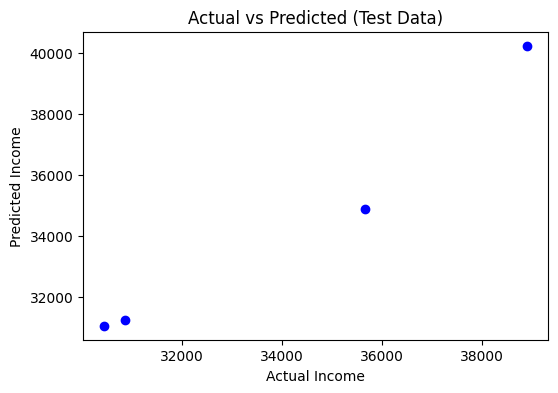

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_test_pred, color='blue')
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual vs Predicted (Test Data)")
plt.show()